In [7]:
import mne
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
edf_path = r'D:\2025_26_internship\bigP3BCI_pipeline\Data\StudyA\A_01\SE001\Train\CB\A_01_SE001_CB_Train01.edf'


# Load the EDF file
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
target_channel = "EEG_Cz"


filtered = raw.copy().filter(l_freq=0.5, h_freq=2.0)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 2.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Filter length: 1691 samples (6.605 s)



C:\Users\qigan\AppData\Local\Temp\ipykernel_32332\2307457974.py:10: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\qigan\AppData\Local\Temp\ipykernel_32332\2307457974.py:10: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


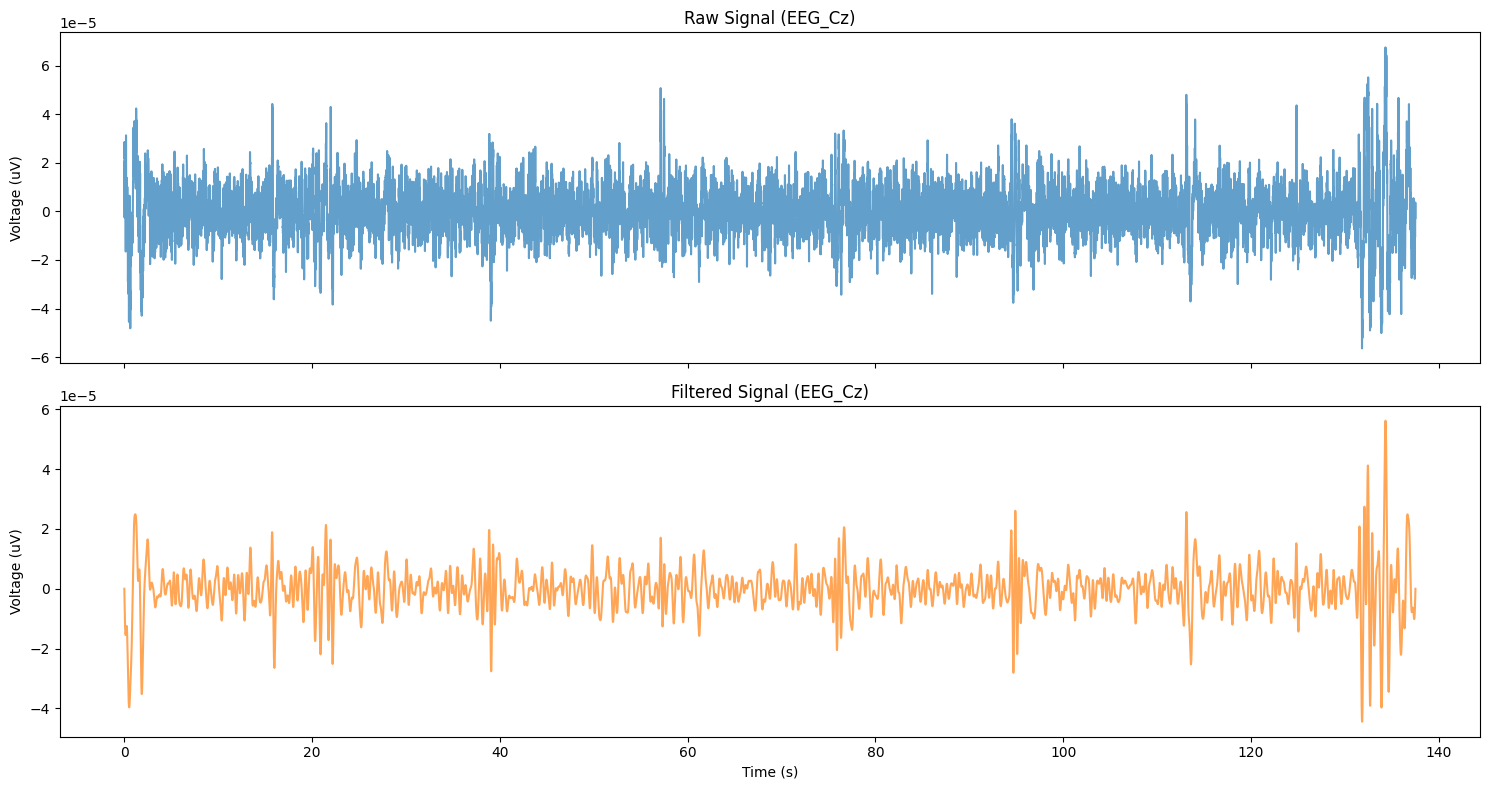

In [8]:
import matplotlib.pyplot as plt

# Get data and times for the desired channel
raw_data, times = raw[target_channel, :]
filtered_data, _ = filtered[target_channel, :]

fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axs[0].plot(times, raw_data[0], color='tab:blue', alpha=0.7)
axs[0].set_title(f"Raw Signal ({target_channel})")
axs[0].set_ylabel('Voltage (uV)')

axs[1].plot(times, filtered_data[0], color='tab:orange', alpha=0.7)
axs[1].set_title(f"Filtered Signal ({target_channel})")
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Voltage (uV)')

plt.tight_layout()
plt.show()
